 # Edge‑IIoTset Full Directory Analysis (PyTorch)



 This notebook loads **all individual CSV files** from the original dataset structure:

 - `Normal traffic/<sensor>/<sensor>.csv`

 - `Attack traffic/<attack_name>.csv`



 It merges them into one big DataFrame, applies cleaning, feature selection,

 scaling, SMOTE, and then trains both classical ML and PyTorch deep learning models

 for intrusion detection. The workflow follows the paper’s Algorithm 1.

 ## 1. Imports & Utilities

In [4]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mat

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

print("All libraries imported successfully.")

import warnings

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {mat.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"PyTorch version: {torch.__version__}")

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


All libraries imported successfully.
NumPy version: 2.2.1
Pandas version: 2.2.3
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
PyTorch version: 2.8.0+cpu
Using device: cpu


 ## 2. Define Paths and Load All CSV Files

In [5]:
# Root directory containing the dataset tree
DATA_ROOT = r"data\\Edge-IIoTset dataset"   # Change to your actual location, e.g. "./Edge-IIoTset"

normal_path = os.path.join(DATA_ROOT, "Normal traffic")
attack_path = os.path.join(DATA_ROOT, "Attack traffic")


In [6]:
MAX_ROWS = 100_000          # only read this many rows per file

normal_dfs = []
print("Loading normal traffic CSV files (sampling):")
for sensor_folder in os.listdir(normal_path):
    folder_path = os.path.join(normal_path, sensor_folder)
    if os.path.isdir(folder_path):
        for fname in os.listdir(folder_path):
            if fname.endswith(".csv"):
                file_path = os.path.join(folder_path, fname)
                print(f"  {sensor_folder}: {fname}  (reading up to {MAX_ROWS} rows)")
                try:
                    # Read only the first MAX_ROWS rows to save memory
                    df_temp = pd.read_csv(file_path, nrows=MAX_ROWS, low_memory=False)
                    df_temp['Attack_label'] = 0
                    df_temp['Attack_type'] = 'Normal'
                    normal_dfs.append(df_temp)
                except MemoryError:
                    print(f"    SKIPPED – still too large, reduce MAX_ROWS or use pre‑selected dataset")


Loading normal traffic CSV files (sampling):
  Distance: Distance.csv  (reading up to 100000 rows)


  Flame_Sensor: Flame_Sensor.csv  (reading up to 100000 rows)
  Heart_Rate: Heart_Rate.csv  (reading up to 100000 rows)
  IR_Receiver: IR_Receiver.csv  (reading up to 100000 rows)
  Modbus: Modbus.csv  (reading up to 100000 rows)
  phValue: phValue.csv  (reading up to 100000 rows)
  Soil_Moisture: Soil_Moisture.csv  (reading up to 100000 rows)
  Sound_Sensor: Sound_Sensor.csv  (reading up to 100000 rows)
  Temperature_and_Humidity: Temperature_and_Humidity.csv  (reading up to 100000 rows)
  Water_Level: Water_Level.csv  (reading up to 100000 rows)


In [7]:
MAX_ROWS = 100_000          # total rows to keep per attack file
CHUNK_SIZE = 50_000         # read 50k rows at a time

attack_dfs = []
print("\nLoading attack traffic CSV files (chunked):")
for fname in os.listdir(attack_path):
    if fname.endswith(".csv"):
        file_path = os.path.join(attack_path, fname)
        print(f"  {fname}")
        chunks = []
        total_rows = 0
        try:
            for chunk in pd.read_csv(file_path, chunksize=CHUNK_SIZE, low_memory=True):
                chunks.append(chunk)
                total_rows += len(chunk)
                if total_rows >= MAX_ROWS:
                    break
            if chunks:
                df_temp = pd.concat(chunks, ignore_index=True)
                # Trim exactly to MAX_ROWS
                df_temp = df_temp.iloc[:MAX_ROWS]
                df_temp['Attack_label'] = 1
                atype = fname.replace(".csv", "")
                df_temp['Attack_type'] = atype
                attack_dfs.append(df_temp)
                print(f"    Loaded {len(df_temp)} rows.")
            else:
                print(f"    Empty file, skipped.")
        except Exception as e:
            print(f"    SKIPPED due to error: {e}")



Loading attack traffic CSV files (chunked):
  Backdoor_attack.csv
    Loaded 24862 rows.
  DDoS_HTTP_Flood_attack.csv
    Loaded 100000 rows.
  DDoS_ICMP_Flood_attack.csv
    Loaded 100000 rows.
  DDoS_TCP_SYN_Flood_attack.csv
    Loaded 100000 rows.
  DDoS_UDP_Flood_attack.csv
    Loaded 100000 rows.
  MITM_attack.csv
    Loaded 1229 rows.
  OS_Fingerprinting_attack.csv
    Loaded 1001 rows.
  Password_attack.csv
    Loaded 100000 rows.
  Port_Scanning_attack.csv
    Loaded 22564 rows.
  Ransomware_attack.csv
    Loaded 10925 rows.
  SQL_injection_attack.csv
    Loaded 51203 rows.
  Uploading_attack.csv
    Loaded 37634 rows.
  Vulnerability_scanner_attack.csv
    Loaded 100000 rows.
  XSS_attack.csv
    Loaded 15915 rows.


In [8]:
# Merge all dataframes
df = pd.concat(normal_dfs + attack_dfs, ignore_index=True)
print(f"\nTotal records loaded: {df.shape[0]}")
print(f"Total columns       : {df.shape[1]}")
df.head(20)


Total records loaded: 1765333
Total columns       : 63


,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,2021 23:58:21.314757000,192.168.1.101,192.168.1.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
1,2021 23:58:21.314960000,192.168.1.101,192.168.1.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
2,2021 23:58:21.315192000,192.168.1.101,192.168.1.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
3,2021 23:58:21.315258000,192.168.1.128,192.168.1.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
4,2021 23:58:21.315294000,192.168.1.101,192.168.1.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
5,2021 23:58:21.315312000,192.168.1.128,192.168.1.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
6,2021 23:58:21.315324000,192.168.1.101,192.168.1.128,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,MQTT,0,0.0,4.0,0.0,0.0,0.0,0,Normal
7,2021 23:58:21.315353000,192.168.1.128,192.168.1.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
8,2021 23:58:21.315711000,192.168.1.128,192.168.1.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
9,2021 23:58:21.319611000,192.168.1.101,192.168.1.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,Distance,8.0,0.0,0.0,0.0,0.0,0,Normal


 ## 3. Initial Data Cleaning



 Following Algorithm 1: drop duplicates, remove missing/infinite values,

 and eliminate non‑informative flow features (IPs, ports, timestamps, payloads, …).

In [9]:
# 3.1 Drop duplicates
print(f"Duplicate rows before: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# 3.2 Replace infinite values with NaN and drop any row containing NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
before = df.shape[0]
df.dropna(inplace=True)
print(f"Dropped {before - df.shape[0]} rows with NaN/inf")

# 3.3 Drop columns that are clearly non‑numeric / not needed for ML
#     (matches the list from the paper: IP addresses, ports, timestamps, payload, etc.)
cols_to_drop = [
    'frame.time', 'ip.src_host', 'ip.dst_host',
    'arp.src.proto_ipv4', 'arp.dst.proto_ipv4',
    'http.file_data', 'http.request.full_uri',
    'icmp.transmit_timestamp', 'http.request.uri.query',
    'tcp.options', 'tcp.payload', 'tcp.srcport', 'tcp.dstport',
    'udp.port', 'mqtt.msg'
]
# Keep only those that exist in the DataFrame
existing_drops = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=existing_drops, inplace=True, errors='ignore')
print(f"Dropped columns: {existing_drops if existing_drops else 'none'}")


Duplicate rows before: 1733
Dropped 0 rows with NaN/inf
Dropped columns: ['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.src.proto_ipv4', 'arp.dst.proto_ipv4', 'http.file_data', 'http.request.full_uri', 'icmp.transmit_timestamp', 'http.request.uri.query', 'tcp.options', 'tcp.payload', 'tcp.srcport', 'tcp.dstport', 'udp.port', 'mqtt.msg']


In [10]:
# Show remaining columns and label distribution
print(f"Remaining shape: {df.shape}")
print("\nBinary label counts:")
print(df['Attack_label'].value_counts())
print("\nAttack type counts:")
print(df['Attack_type'].value_counts())


Remaining shape: (1763600, 48)

Binary label counts:


Attack_label
0    999089
1    764511
Name: count, dtype: int64

Attack type counts:
Attack_type
Normal                          999089
DDoS_HTTP_Flood_attack          100000
DDoS_ICMP_Flood_attack          100000
DDoS_TCP_SYN_Flood_attack       100000
Password_attack                 100000
Vulnerability_scanner_attack    100000
DDoS_UDP_Flood_attack            99997
SQL_injection_attack             51203
Uploading_attack                 37634
Backdoor_attack                  24862
Port_Scanning_attack             22564
XSS_attack                       15915
Ransomware_attack                10925
OS_Fingerprinting_attack          1001
MITM_attack                        410
Name: count, dtype: int64


 ## 4. Exploratory Data Analysis

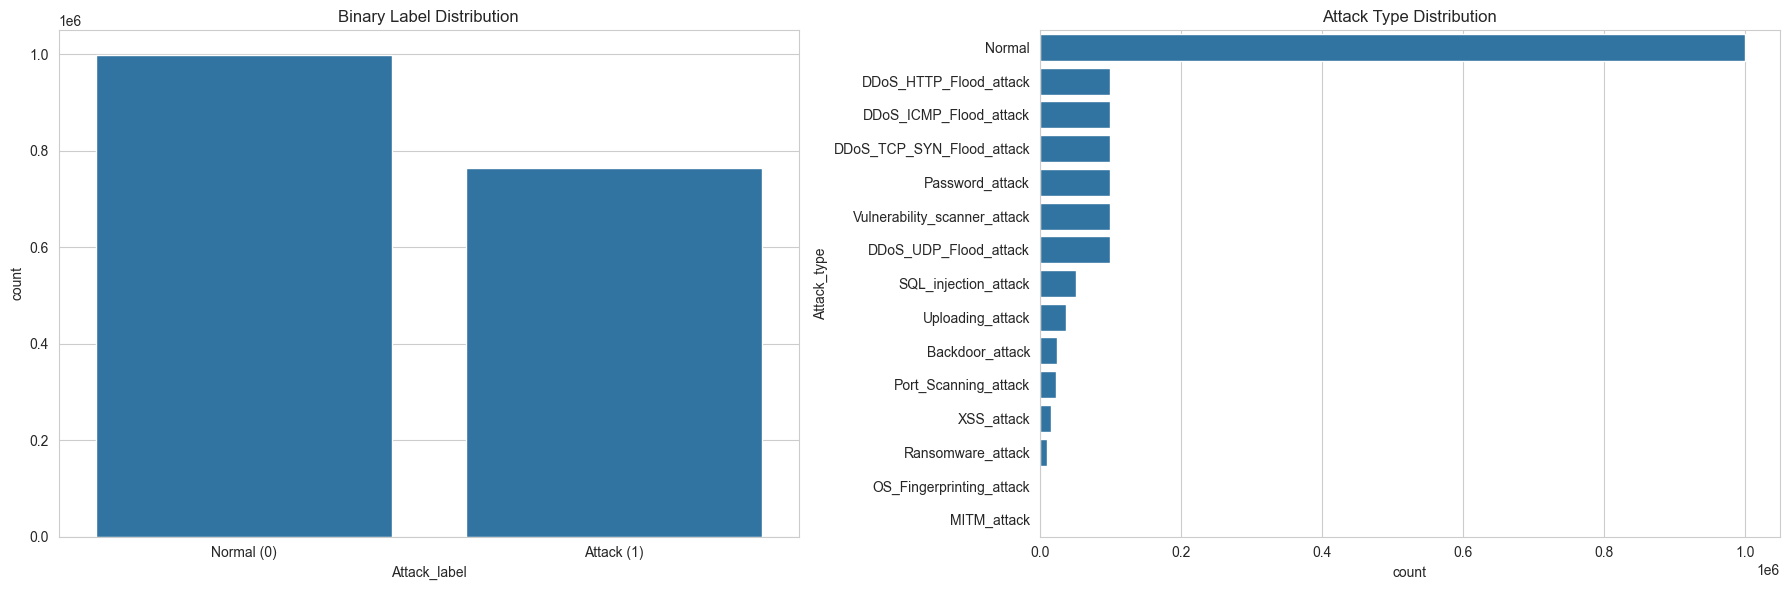

In [11]:
# Class distribution plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.countplot(x='Attack_label', data=df, ax=axes[0])
axes[0].set_title('Binary Label Distribution')
axes[0].set_xticklabels(['Normal (0)', 'Attack (1)'])

order = df['Attack_type'].value_counts().index
sns.countplot(y='Attack_type', data=df, order=order, ax=axes[1])
axes[1].set_title('Attack Type Distribution')
plt.tight_layout()
plt.show()


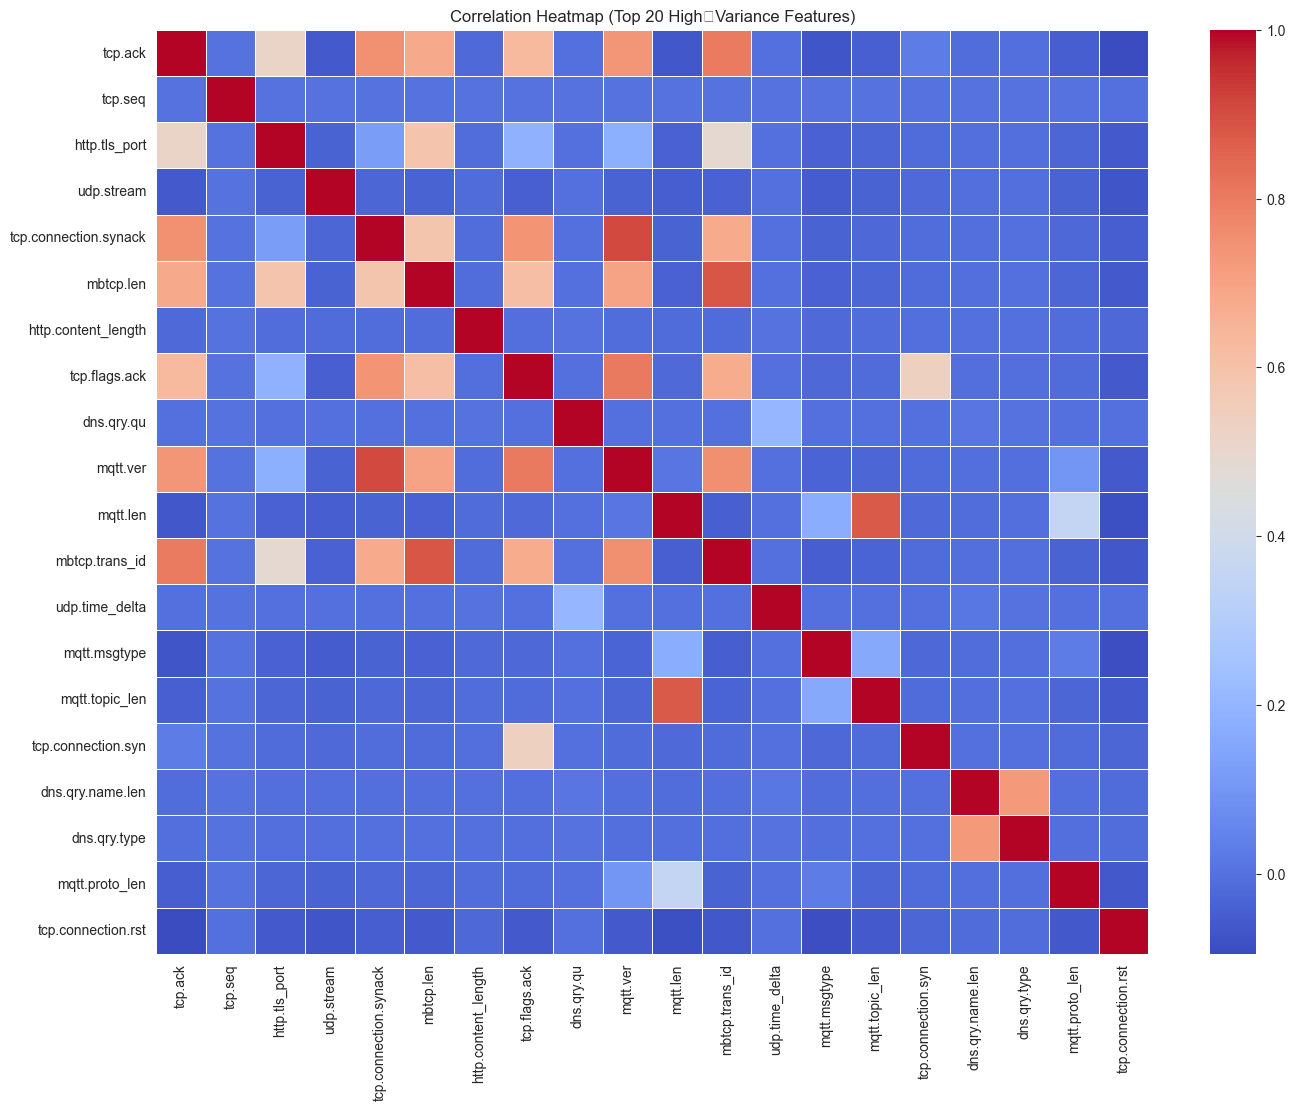

In [12]:
# Feature correlation (select numeric columns only)
feature_cols = df.select_dtypes(include=[np.number]).columns.drop('Attack_label')
variances = df[feature_cols].var().sort_values(ascending=False).head(20)
top_features = variances.index.tolist()
if top_features:
    plt.figure(figsize=(16, 12))
    sns.heatmap(df[top_features].corr(), annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Heatmap (Top 20 High‑Variance Features)')
    plt.show()


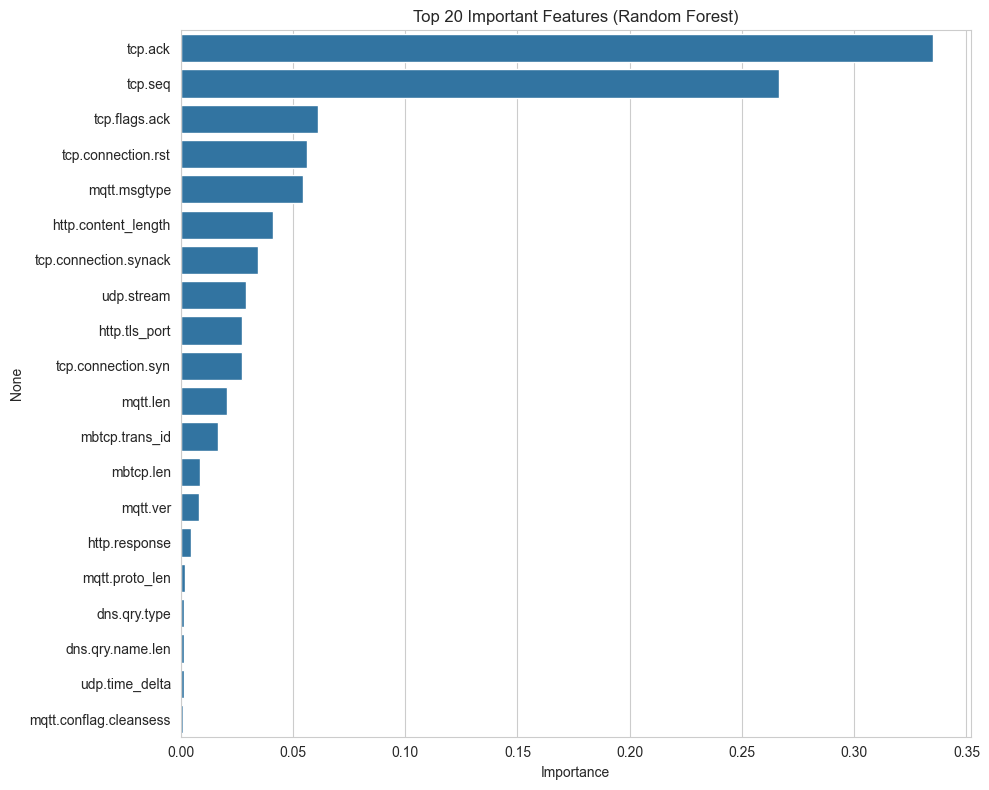

In [13]:
# Random Forest feature importance (on a 10% sample)
sample_df = df.sample(frac=0.1, random_state=42)
X_sample = sample_df[feature_cols]
y_sample = sample_df['Attack_label']
rf_imp = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_imp.fit(X_sample, y_sample)
importances = pd.Series(rf_imp.feature_importances_, index=feature_cols).sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Top 20 Important Features (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


 ## 5. Data Preprocessing



 - Separate features and labels

 - Encode multi‑class labels (15‑class and 6‑class mapping)

 - Train‑test split (stratified)

 - Standardize

 - SMOTE on training set

In [14]:
# Features: all numeric columns except labels
X = df[feature_cols].copy()
y_binary = df['Attack_label']

# Multi‑class encoding (15 classes)
le = LabelEncoder()
y_15class = le.fit_transform(df['Attack_type'])

# 6‑class mapping as in the paper
def map_to_6class(attack_type):
    if attack_type == 'Normal':
        return 0
    elif attack_type in ['DDoS_HTTP_Flood_attack','DDoS_ICMP_Flood_attack',
                         'DDoS_TCP_SYN_Flood_attack','DDoS_UDP_Flood_attack']:
        return 1
    elif attack_type in ['SQL_injection_attack','XSS_attack','Uploading_attack']:
        return 2
    elif attack_type in ['MITM_attack']:
        return 3
    elif attack_type in ['Backdoor_attack','Password_attack','Ransomware_attack']:
        return 4
    elif attack_type in ['Port_Scanning_attack','OS_Fingerprinting_attack',
                         'Vulnerability_scanner_attack']:
        return 5
    else:
        return -1

y_6class = df['Attack_type'].apply(map_to_6class)


In [15]:
# Train‑test splits (stratified)
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

X_train_15, X_test_15, y_train_15, y_test_15 = train_test_split(
    X, y_15class, test_size=0.2, random_state=42, stratify=y_15class)

X_train_6, X_test_6, y_train_6, y_test_6 = train_test_split(
    X, y_6class, test_size=0.2, random_state=42, stratify=y_6class)

print("Train / Test sizes:")
print(f"Binary: {X_train_bin.shape[0]} / {X_test_bin.shape[0]}")
print(f"15‑Class: {X_train_15.shape[0]} / {X_test_15.shape[0]}")
print(f"6‑Class:  {X_train_6.shape[0]} / {X_test_6.shape[0]}")


Train / Test sizes:
Binary: 1410880 / 352720
15‑Class: 1410880 / 352720
6‑Class:  1410880 / 352720


In [16]:
# Standardization
scaler = StandardScaler()
X_train_bin_scaled = scaler.fit_transform(X_train_bin)
X_test_bin_scaled  = scaler.transform(X_test_bin)

scaler15 = StandardScaler()
X_train_15_scaled = scaler15.fit_transform(X_train_15)
X_test_15_scaled  = scaler15.transform(X_test_15)

scaler6 = StandardScaler()
X_train_6_scaled = scaler6.fit_transform(X_train_6)
X_test_6_scaled  = scaler6.transform(X_test_6)


In [17]:
from tqdm import tqdm

sm = SMOTE(random_state=42)

print("Applying SMOTE …")
with tqdm(total=3, desc="SMOTE Progress") as pbar:
    X_train_bin_res, y_train_bin_res = sm.fit_resample(X_train_bin_scaled, y_train_bin)
    pbar.update(1)
    pbar.set_postfix_str("Binary done")

    X_train_15_res, y_train_15_res = sm.fit_resample(X_train_15_scaled, y_train_15)
    pbar.update(1)
    pbar.set_postfix_str("15‑Class done")

    X_train_6_res,  y_train_6_res  = sm.fit_resample(X_train_6_scaled, y_train_6)
    pbar.update(1)
    pbar.set_postfix_str("6‑Class done")

print(f"After SMOTE – Binary: {X_train_bin_res.shape[0]}, 15‑class: {X_train_15_res.shape[0]}, 6‑class: {X_train_6_res.shape[0]}")

Applying SMOTE …


SMOTE Progress: 100%|██████████| 3/3 [35:40<00:00, 713.58s/it, 6‑Class done] 

After SMOTE – Binary: 1598542, 15‑class: 11989065, 6‑class: 4795626


 ## 6. Classical Machine Learning Models

In [18]:
def eval_sklearn(model, X_train, y_train, X_test, y_test, class_names, multi=False):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    average = 'macro' if multi else 'binary'
    prec = precision_score(y_test, y_pred, average=average)
    rec  = recall_score(y_test, y_pred, average=average)
    f1   = f1_score(y_test, y_pred, average=average)

    print(f"{model.__class__.__name__:>20s} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
    return acc, f1

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    # 'SVM': SVC(kernel='linear', random_state=42),
    'k‑NN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

class_names_6  = ['Normal','DDoS','Injection','MITM','Malware','Scanning']
class_names_15 = le.classes_.tolist()


In [19]:
print("\n=== Binary Classification ===")
for name, model in models.items():
    eval_sklearn(model, X_train_bin_res, y_train_bin_res, X_test_bin_scaled, y_test_bin,
                 ['Normal','Attack'])

print("\n=== 6‑Class Classification ===")
for name, model in models.items():
    eval_sklearn(model, X_train_6_res, y_train_6_res, X_test_6_scaled, y_test_6,
                 class_names_6, multi=True)

print("\n=== 15‑Class Classification ===")
for name, model in models.items():
    eval_sklearn(model, X_train_15_res, y_train_15_res, X_test_15_scaled, y_test_15,
                 class_names_15, multi=True)



=== Binary Classification ===


DecisionTreeClassifier | Acc: 0.9257 | Prec: 0.8703 | Rec: 0.9736 | F1: 0.9191
RandomForestClassifier | Acc: 0.9257 | Prec: 0.8703 | Rec: 0.9737 | F1: 0.9191
KNeighborsClassifier | Acc: 0.9017 | Prec: 0.9179 | Rec: 0.8492 | F1: 0.8822

=== 6‑Class Classification ===
DecisionTreeClassifier | Acc: 0.8308 | Prec: 0.8348 | Rec: 0.8582 | F1: 0.8103
RandomForestClassifier | Acc: 0.8308 | Prec: 0.8349 | Rec: 0.8583 | F1: 0.8104
KNeighborsClassifier | Acc: 0.8492 | Prec: 0.7516 | Rec: 0.7850 | F1: 0.6730

=== 15‑Class Classification ===
DecisionTreeClassifier | Acc: 0.8289 | Prec: 0.7279 | Rec: 0.6976 | F1: 0.6861


MemoryError: Unable to allocate 91.5 MiB for an array with shape (11989065,) and data type int64

 ## 7. Deep Neural Networks (PyTorch)



 Architecture from the paper: 2 hidden layers × 90 neurons, ReLU,

 L2 reg via `weight_decay`, softmax output, Adam optimizer.

 Batch size = 800, epochs = 10 (reduced for demo).

In [ ]:
def create_dataloader(X, y, batch_size=800, shuffle=True):
    tensor_x = torch.FloatTensor(X)
    tensor_y = torch.LongTensor(y)
    dataset = TensorDataset(tensor_x, tensor_y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 90)
        self.fc2 = nn.Linear(90, 90)
        self.fc3 = nn.Linear(90, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def train_model(model, train_loader, test_loader, epochs=10, lr=0.001, wd=1e-3):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, epochs+1):
        model.train()
        total_loss, correct = 0, 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()

        # Evaluation
        model.eval()
        test_loss, test_correct = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                test_loss += criterion(output, target).item() * data.size(0)
                test_correct += output.argmax(dim=1).eq(target).sum().item()

        train_acc = correct / len(train_loader.dataset)
        test_acc = test_correct / len(test_loader.dataset)
        print(f"Epoch {epoch:2d}: Train Acc {train_acc:.4f} | Test Acc {test_acc:.4f}")
    return model


In [ ]:
input_dim = X_train_bin_res.shape[1]

# --- Binary ---
print("\n=== Training Binary DNN ===")
train_loader_bin = create_dataloader(X_train_bin_res, y_train_bin_res)
test_loader_bin  = create_dataloader(X_test_bin_scaled, y_test_bin, shuffle=False)
model_bin = MLP(input_dim, 2)
model_bin = train_model(model_bin, train_loader_bin, test_loader_bin, epochs=10)

# --- 6‑Class ---
print("\n=== Training 6‑Class DNN ===")
train_loader_6 = create_dataloader(X_train_6_res, y_train_6_res)
test_loader_6  = create_dataloader(X_test_6_scaled, y_test_6, shuffle=False)
model_6 = MLP(input_dim, 6)
model_6 = train_model(model_6, train_loader_6, test_loader_6, epochs=10)

# --- 15‑Class ---
print("\n=== Training 15‑Class DNN ===")
train_loader_15 = create_dataloader(X_train_15_res, y_train_15_res)
test_loader_15  = create_dataloader(X_test_15_scaled, y_test_15, shuffle=False)
model_15 = MLP(input_dim, 15)
model_15 = train_model(model_15, train_loader_15, test_loader_15, epochs=10)


 ## 8. Summary & Next Steps



 The notebook successfully loaded **all raw CSV files** from the original dataset structure,

 merged them, cleaned the data, and trained both traditional ML and PyTorch DNN models.

 Results will reflect the quality of the original per‑sensor/attack features (which may differ

 from the paper’s 61 pre‑extracted features). To replicate the paper’s exact numbers, you can

 use the `DNN-EdgeIIoT-dataset.csv` file directly with the same PyTorch code.



 Adjust the `DATA_ROOT` path if your dataset is located elsewhere. You can also increase

 the number of training epochs for better accuracy.